# Bixi Montreal 2024 - Data Analysis
Analyzing 13 million bike trips to understand how Montrealers move around the city.

Data source: BIXI Montreal Open Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
df = pd.read_csv('data/DonneesOuvertes (2).csv')
df['start_time'] = pd.to_datetime(df['STARTTIMEMS'], unit='ms')
df['end_time'] = pd.to_datetime(df['ENDTIMEMS'], unit='ms')
df['duration_min'] = (df['end_time'] - df['start_time']).dt.total_seconds() / 60
df['hour'] = df['start_time'].dt.hour
df['day_of_week'] = df['start_time'].dt.day_name()
df['month'] = df['start_time'].dt.month
df['month_name'] = df['start_time'].dt.month_name()
df_clean = df[(df['duration_min'] >= 1) & (df['duration_min'] <= 180)]
print(f'Total trips: {len(df_clean):,}')

Total trips: 12,974,146


## 1. Trips by Hour of Day

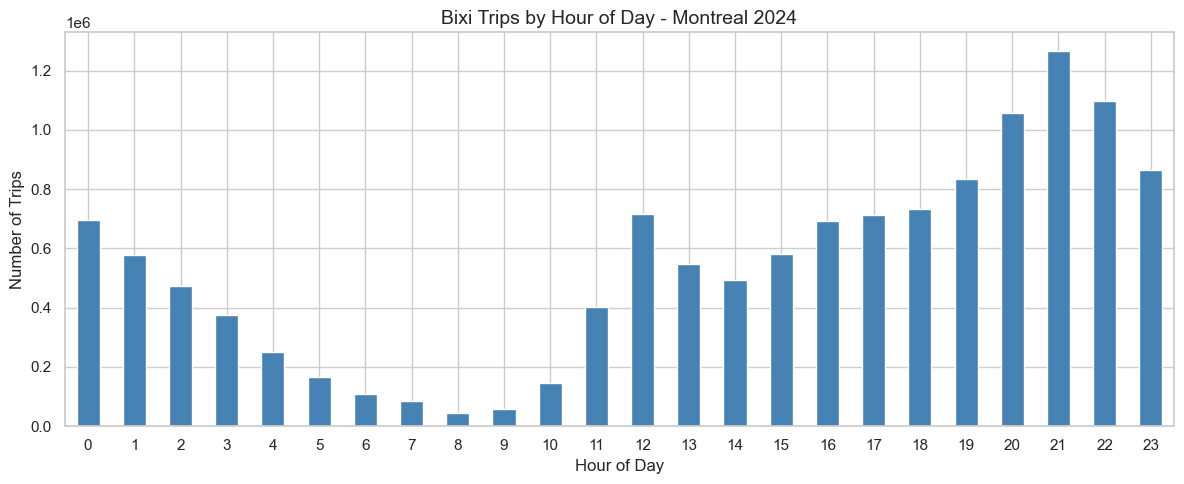

In [2]:
plt.figure(figsize=(12, 5))
df_clean['hour'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Bixi Trips by Hour of Day - Montreal 2024', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('trips_by_hour.png', dpi=150)
plt.show()

## 2. Trips by Month

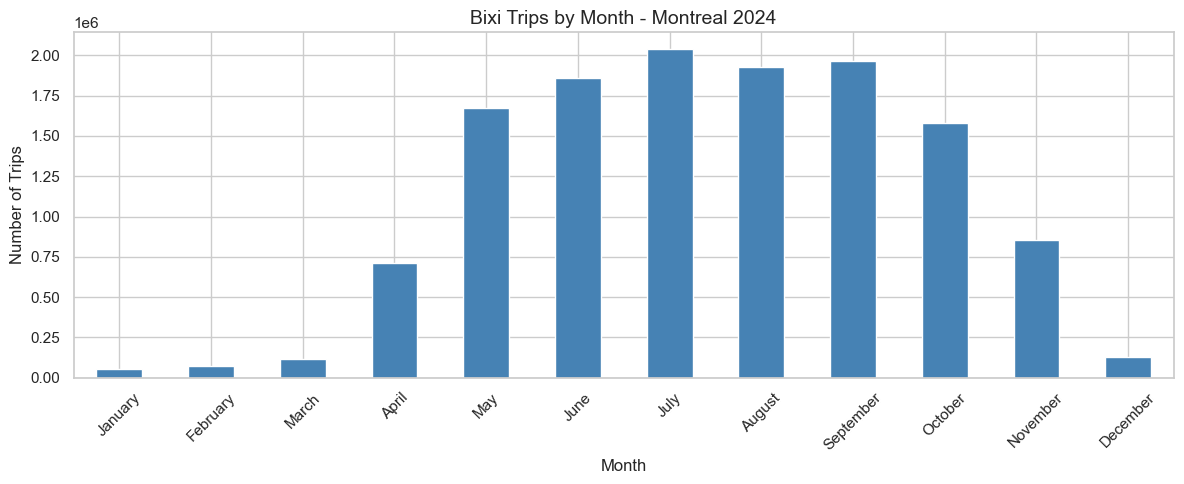

In [3]:
month_order = df_clean.groupby('month')['month_name'].first()
monthly_counts = df_clean.groupby('month').size()
monthly_counts.index = month_order.values
plt.figure(figsize=(12, 5))
monthly_counts.plot(kind='bar', color='steelblue')
plt.title('Bixi Trips by Month - Montreal 2024', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('trips_by_month.png', dpi=150)
plt.show()

## 3. Top 10 Busiest Stations

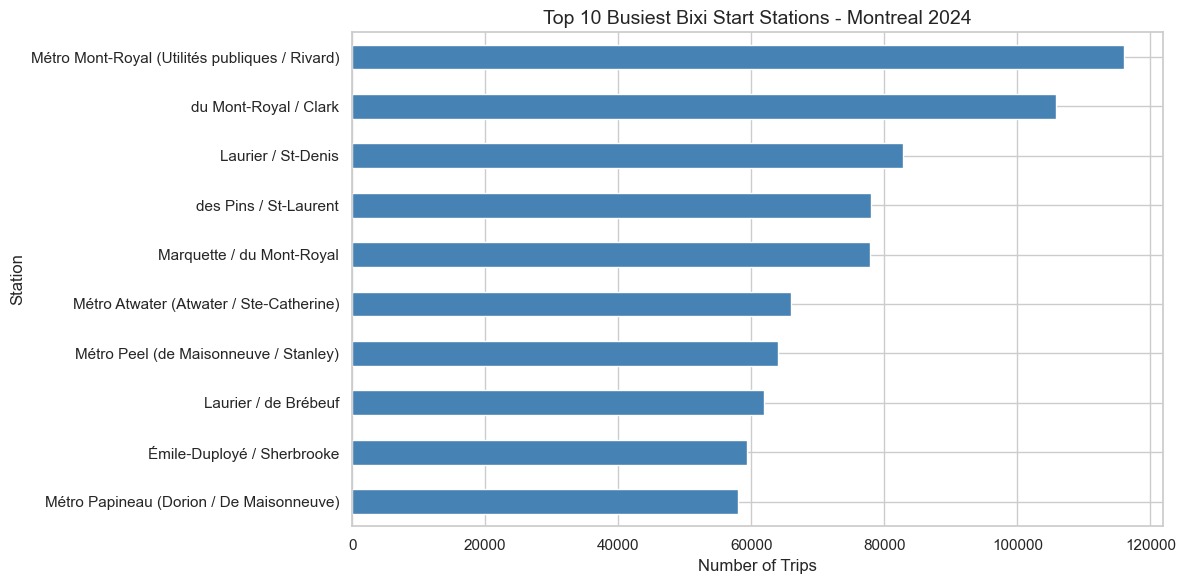

In [4]:
top_stations = df_clean['STARTSTATIONNAME'].value_counts().head(10)
plt.figure(figsize=(12, 6))
top_stations.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Busiest Bixi Start Stations - Montreal 2024', fontsize=14)
plt.xlabel('Number of Trips')
plt.ylabel('Station')
plt.tight_layout()
plt.savefig('top_stations.png', dpi=150)
plt.show()

## 4. Trips by Day of Week

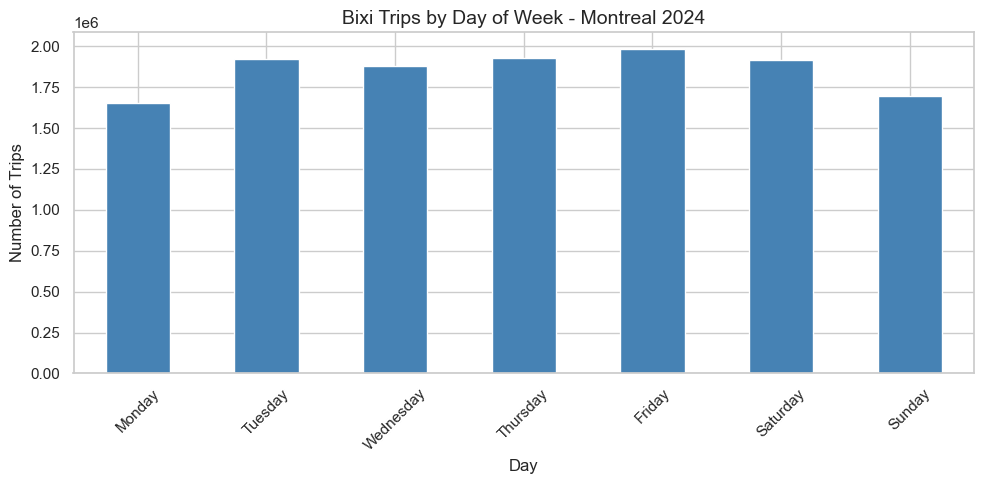

In [5]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df_clean['day_of_week'].value_counts().reindex(day_order)
plt.figure(figsize=(10, 5))
day_counts.plot(kind='bar', color='steelblue')
plt.title('Bixi Trips by Day of Week - Montreal 2024', fontsize=14)
plt.xlabel('Day')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('trips_by_day.png', dpi=150)
plt.show()

## 5. Average Trip Duration by Borough

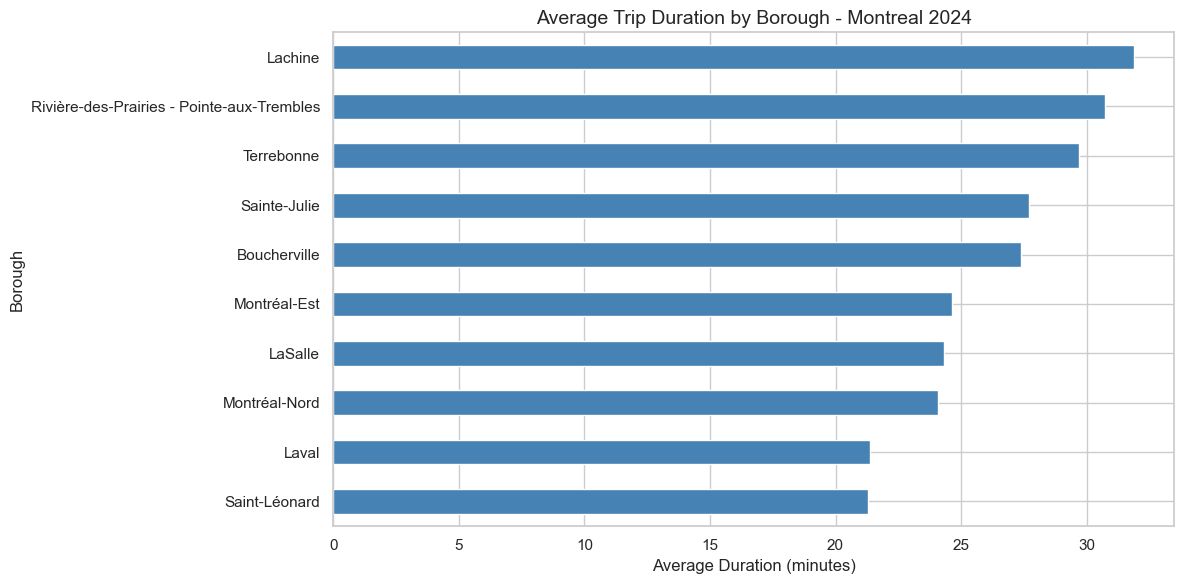

In [6]:
borough_duration = df_clean.groupby('STARTSTATIONARRONDISSEMENT')['duration_min'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
borough_duration.sort_values().plot(kind='barh', color='steelblue')
plt.title('Average Trip Duration by Borough - Montreal 2024', fontsize=14)
plt.xlabel('Average Duration (minutes)')
plt.ylabel('Borough')
plt.tight_layout()
plt.savefig('duration_by_borough.png', dpi=150)
plt.show()

## 6. Top 10 Most Popular Routes

/var/folders/v7/lwqtq6_s3f14z2x2v7vnnblh0000gn/T/ipykernel_29217/2412726076.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['route'] = df_clean['STARTSTATIONNAME'] + ' to ' + df_clean['ENDSTATIONNAME']


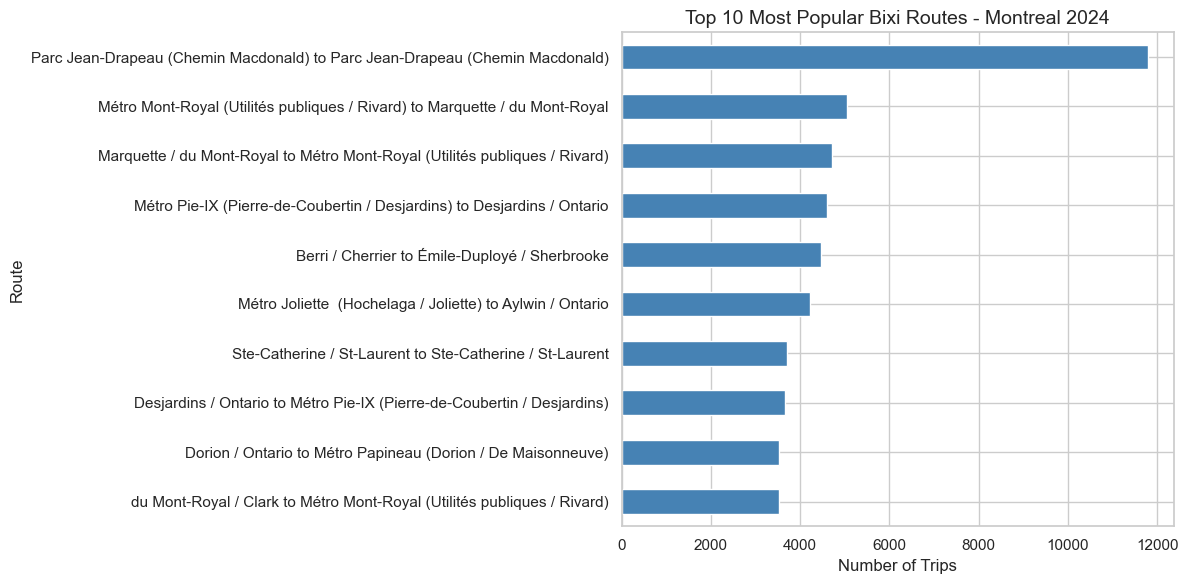

In [7]:
df_clean['route'] = df_clean['STARTSTATIONNAME'] + ' to ' + df_clean['ENDSTATIONNAME']
top_routes = df_clean['route'].value_counts().head(10)
plt.figure(figsize=(12, 6))
top_routes.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Most Popular Bixi Routes - Montreal 2024', fontsize=14)
plt.xlabel('Number of Trips')
plt.ylabel('Route')
plt.tight_layout()
plt.savefig('top_routes.png', dpi=150)
plt.show()